# MA03 — Data Challenge



In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import OneHotEncoder

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', 40)

train_df = pd.read_csv('listings_train.csv')
test_df = pd.read_csv('listings_test_features.csv')

print(f"Training set: {train_df.shape[0]} rows, {train_df.shape[1]} columns")
print(f"Test set:     {test_df.shape[0]} rows, {test_df.shape[1]} columns")

Training set: 42234 rows, 36 columns
Test set:     8199 rows, 35 columns


## Q0 — Framing

This is supervised regression problem as there is a continuous numeric target column price and a set of input features for each listing with the goal being to map features to price.

## Q1 — Data Quality

In [68]:
# Column comparison between train and test
train_cols = set(train_df.columns)
test_cols = set(test_df.columns)

print(f"Training columns:  {len(train_df.columns)}")
print(f"Test columns:      {len(test_df.columns)}")
print(f"Values only found in train: {train_cols - test_cols}")
print(f"Training rows:     {len(train_df)}")
print(f"Test rows:         {len(test_df)}")

Training columns:  36
Test columns:      35
Values only found in train: {'price'}
Training rows:     42234
Test rows:         8199


In [69]:
# Missing values in training set
missing_train = train_df.isnull().sum()
missing_train = missing_train[missing_train > 0].sort_values(ascending=False)
print("Missing values in training set:")
print(missing_train.to_string())

# Missing values in test set
missing_test = test_df.isnull().sum()
missing_test = missing_test[missing_test > 0].sort_values(ascending=False)
print("\nMissing values in test set:")
print(missing_test.to_string())

Missing values in training set:
license                        42234
neighbourhood_group            42234
review_scores_value             9137
review_scores_location          9137
review_scores_checkin           9137
review_scores_communication     9136
review_scores_cleanliness       9136
review_scores_accuracy          9136
reviews_per_month               9135
last_review                     9135
review_scores_rating            9135
beds                              80
bedrooms                          47
bathrooms                         42
host_name                         18
host_total_listings_count         16
host_identity_verified            16
host_has_profile_pic              16

Missing values in test set:
neighbourhood_group    8199
license                8199


Q1: Data Quality **(answers written here are supported by code above)**
There are a total of 36 columns in training set and 35 in the test set. The only mismatch as the training set has a price column while test set does not. Training set has 42,234 rows while test set has 8,199 rows. If we use the rows as is, none of them are usable as they are missing at least values in the license and neighborhood_group columns.  




## Q2 — Distributions

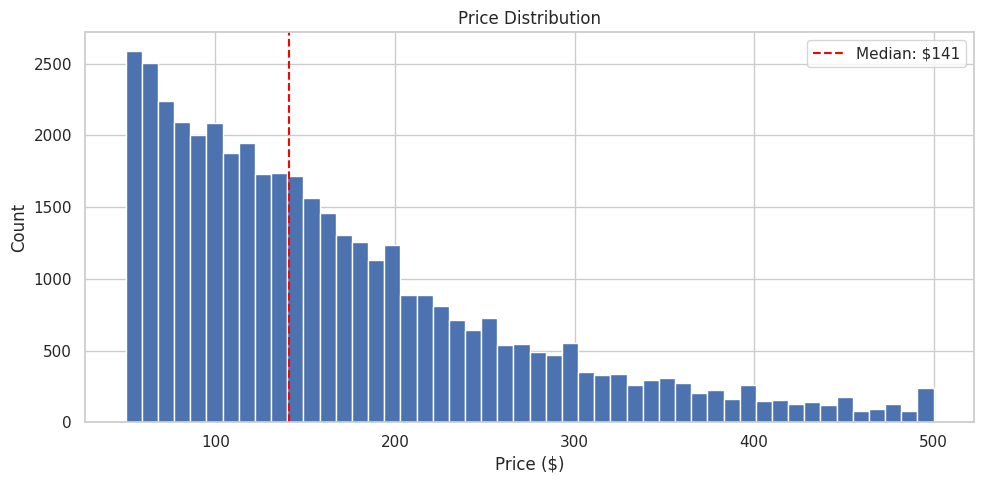

Median price: $141
Mean price:   $166.24
Skewness:     1.18


In [87]:
# Price distribution
plt.figure(figsize=(10, 5))
plt.hist(train_df['price'], bins=50)
plt.title('Price Distribution')
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.axvline(train_df['price'].median(), color='red', linestyle='--',
            label=f"Median: ${train_df['price'].median():.0f}")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Median price: ${train_df['price'].median():.0f}")
print(f"Mean price:   ${train_df['price'].mean():.2f}")
print(f"Skewness:     {train_df['price'].skew():.2f}")

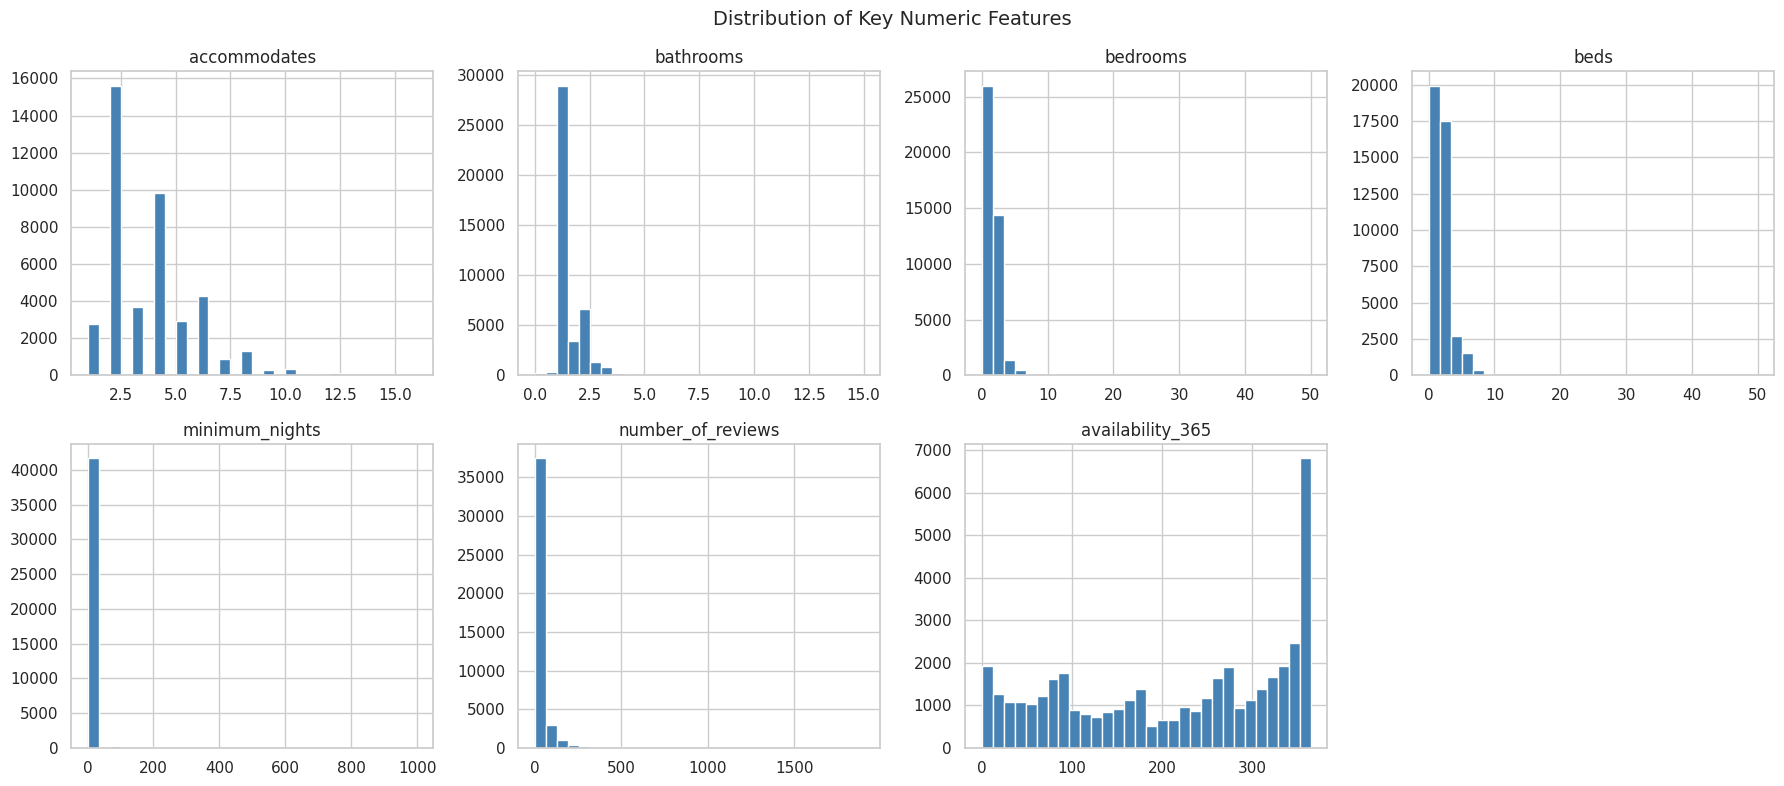

In [88]:
# Distribution of key numeric features
numeric_cols = ['accommodates', 'bathrooms', 'bedrooms', 'beds',
                'minimum_nights', 'number_of_reviews', 'availability_365']
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    axes[i].hist(train_df[col].dropna(), bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Distribution of Key Numeric Features', fontsize=14)
plt.tight_layout()
plt.show()

In [72]:
# Non-numeric columns: unique values
non_numeric = ['room_type', 'neighbourhood', 'host_has_profile_pic', 'host_identity_verified']
for col in non_numeric:
    print(f"{col}: {train_df[col].nunique()} unique values")

room_type: 4 unique values
neighbourhood: 33 unique values
host_has_profile_pic: 2 unique values
host_identity_verified: 2 unique values


Q2: Distributions **(answers written here are supported by code above)**

Price is not normally distributed and the median price is about $141. The features are not normally distributed as well and like the price, are mainly right-skewed with a few out-liers. Room type has 4 unique values, neighborhood has 3, and both host has profile pic and host identity verified have 2. I intend to use sklearn's onehotencoder for neighborhood and room type while using true and false for the host's characteristics.

## Q3 — Price vs. Minimum Nights

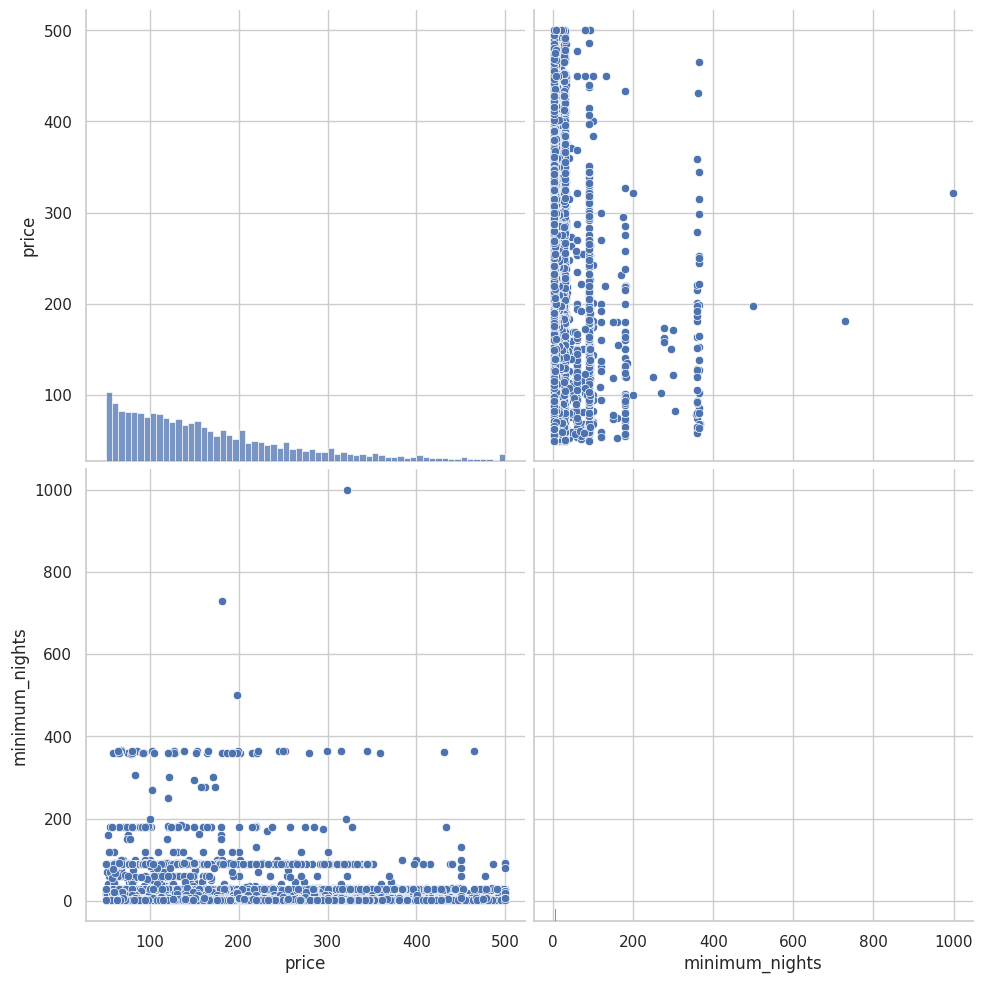

In [73]:
# Pairplot of price and minimum_nights
sns.pairplot(train_df[['price', 'minimum_nights']], height = 5)
plt.show()



There is no observable and meaningful correlation between price and minimum_nights; the scatter plot in the bottom-left shows no visible trend showing a consistent pattern between the two columns.

# Data Cleansing / Feature Engineering

In [74]:
def clean_and_engineer(df):
    """Apply all cleaning and feature-engineering steps consistently."""
    df = df.copy()

    # Drop columns that are fully null or not useful for prediction
    drop_cols = ['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
                 'license', 'last_review', 'amenities']
    df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)

    # Binary encoding for t/f columns
    for col in ['host_has_profile_pic', 'host_identity_verified']:
        df[col] = df[col].map({'t': 1, 'f': 0})

    # has_reviews flag + fill reviews_per_month with 0 for no-review listings
    df['has_reviews'] = (df['number_of_reviews'] > 0).astype(int)
    df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

    # Fill remaining missing numeric columns with median
    numeric_fill = ['host_total_listings_count', 'host_has_profile_pic',
                    'host_identity_verified', 'bathrooms', 'bedrooms', 'beds',
                    'review_scores_rating', 'review_scores_accuracy',
                    'review_scores_cleanliness', 'review_scores_checkin',
                    'review_scores_communication', 'review_scores_location',
                    'review_scores_value']
    for col in numeric_fill:
        if col in df.columns and df[col].isnull().any():
            df[col] = df[col].fillna(df[col].median())

    return df

# Extract amenity count before cleaning drops the amenities column
train_df['amenity_count'] = train_df['amenities'].apply(
    lambda x: len(str(x).split(',')) if pd.notna(x) else 0
)
test_df['amenity_count'] = test_df['amenities'].apply(
    lambda x: len(str(x).split(',')) if pd.notna(x) else 0
)

train_clean = clean_and_engineer(train_df)
test_clean = clean_and_engineer(test_df)

print(f"Train after cleaning: {train_clean.shape}")
print(f"Test after cleaning:  {test_clean.shape}")
print(f"Remaining nulls in train: {train_clean.isnull().sum().sum()}")
print(f"Remaining nulls in test:  {test_clean.isnull().sum().sum()}")

Train after cleaning: (42234, 30)
Test after cleaning:  (8199, 29)
Remaining nulls in train: 0
Remaining nulls in test:  0


# Model Preparation

In [75]:
# Separate target
y_full = train_clean['price']
X_full = train_clean.drop(columns=['price'])

# One-hot encode categorical columns using sklearn (so same encoder applies to test)
cat_cols = ['room_type', 'neighbourhood']

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoder.fit(X_full[cat_cols])

def apply_encoding(df, encoder, cat_cols):
    """One-hot encode categorical columns and concatenate with numeric columns."""
    encoded = pd.DataFrame(
        encoder.transform(df[cat_cols]),
        columns=encoder.get_feature_names_out(cat_cols),
        index=df.index
    )
    return pd.concat([df.drop(columns=cat_cols).reset_index(drop=True),
                      encoded.reset_index(drop=True)], axis=1)

X_full = apply_encoding(X_full, encoder, cat_cols)
X_test_final = apply_encoding(test_clean, encoder, cat_cols)

print(f"Feature matrix (train): {X_full.shape}")
print(f"Feature matrix (test):  {X_test_final.shape}")

Feature matrix (train): (42234, 64)
Feature matrix (test):  (8199, 64)


In [76]:
# Internal train/validation split for model development
X_train, X_val, y_train, y_val = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42
)
print(f"Training split:   {X_train.shape[0]} rows")
print(f"Validation split: {X_val.shape[0]} rows")

Training split:   33787 rows
Validation split: 8447 rows


# Algorithms used: Linear regression + decision tree

Averaging predictions from two different model families (linear + tree-based) often reduces error because they make different kinds of mistakes.

In [77]:
# Test different weighting ratios for the ensemble
ensemble_results = {}
for w_lr in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_pred_ens = w_lr * y_pred_lr + (1 - w_lr) * y_pred_dt_best
    rmse_ens = np.sqrt(mean_squared_error(y_val, y_pred_ens))
    ensemble_results[w_lr] = rmse_ens
    print(f"  LR weight={w_lr:.1f}, DT weight={1-w_lr:.1f}  →  RMSE: {rmse_ens:.2f}")

best_w = min(ensemble_results, key=ensemble_results.get)
rmse_ensemble = ensemble_results[best_w]
print(f"\nBest ensemble: LR weight={best_w:.1f} (RMSE: {rmse_ensemble:.2f})")

  LR weight=0.3, DT weight=0.7  →  RMSE: 61.22
  LR weight=0.4, DT weight=0.6  →  RMSE: 60.92
  LR weight=0.5, DT weight=0.5  →  RMSE: 60.96
  LR weight=0.6, DT weight=0.4  →  RMSE: 61.36
  LR weight=0.7, DT weight=0.3  →  RMSE: 62.08

Best ensemble: LR weight=0.4 (RMSE: 60.92)


# Predictions

Retrain the best models (Linear Regression + Decision Tree) on the **full** training set, then combine their predictions using the optimal weight.

In [78]:
# Retrain both models on the full training data
lr_final = LinearRegression()
lr_final.fit(X_full, y_full)

dt_final = DecisionTreeRegressor(max_depth=best_depth, min_samples_leaf=best_leaf, random_state=42)
dt_final.fit(X_full, y_full)

# Generate ensemble predictions on the test set
pred_lr_test = lr_final.predict(X_test_final)
pred_dt_test = dt_final.predict(X_test_final)
final_predictions = best_w * pred_lr_test + (1 - best_w) * pred_dt_test

# Clip to reasonable range (no negative prices)
final_predictions = np.clip(final_predictions, 0, None)

print(f"Final predictions — min: ${final_predictions.min():.1f}, "
      f"max: ${final_predictions.max():.1f}, mean: ${final_predictions.mean():.1f}")

Final predictions — min: $19.4, max: $426.9, mean: $163.2


In [79]:
# Save predictions to CSV
output = pd.DataFrame({'price': final_predictions})
output.to_csv('predicted_price.csv', index=False)
print(f"Saved {len(output)} predictions to predicted_price.csv")
print(f"first 10 predictions\n", output.head(10))

Saved 8199 predictions to predicted_price.csv
first 10 predictions
         price
0  236.555985
1  119.899653
2  186.205743
3  247.828828
4  285.182254
5   69.245848
6  191.307274
7  279.354045
8  132.003668
9   68.947579


# Reflection

**1. Which features were most predictive of nightly price?**

Features such as accommodations, bedrooms, room_type were some of the most predictive of the nightly price; properties that host a larger amount of guests means higher prices, and location is a classic driver of accommodation pricing. Amenities are also a large contributor as the more professionally managed a place is and the variety of accomodations there are (AC, pool, wine cabinet, etc), the more likely the price would increase.  

**2. What does your model reveal about these Airbnb markets?**

The Linear Regression and Decision Tree model revealed that there are many features that show consistent patterns. Moreover, the neighborhood significantly impacts the price as the nicer the view, the higher the price. The property characteristics (room type, bedrooms, accomodations, etc) also show higher influence over review ratings, which suggests that the listing for a property matters more than people's personal opinions on their experience.

**3. What additional data would improve the model?**

I think the model would improve if we included travel time to popular destinations or even what attractions are in the area that are worth going to. Even simple data such as restaurant locations and weather patterns would improve the model by quite a bit.